In [ ]:
#1. Simple Linear Regression
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error, r2_score

# Membuat data sintetis: y = 3x + 2 + noise
np.random.seed(42)                       # agar hasil bisa direproduksi (opsional tapi disarankan)
X = np.random.rand(100, 1) * 10         # 100 titik data, fitur antara 0–10
y = 3*X[:, 0] + 2 + np.random.randn(100) # target = 3x + 2, ditambah noise acak

# Membagi data: 80% latih, 20% uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Melatih model lalu memprediksi data uji
model = LinearRegression().fit(X_train, y_train)
y_pred = model.predict(X_test)

# Evaluasi: R² mendekati 1 = bagus, RMSE mendekati 0 = bagus
print("R2:", round(r2_score(y_test, y_pred), 3))
print("RMSE:", round(root_mean_squared_error(y_test, y_pred), 3))

R2: 0.992
RMSE: 0.809


In [ ]:
#2. Multiple Linear Regression
from sklearn.datasets import fetch_california_housing
import pandas as pd

# Dataset California Housing: ~20 ribu rumah, 8 fitur, target = median harga rumah.
data = fetch_california_housing(as_frame=True)
X = data.frame.drop(columns=["MedHouseVal"])  # semua kolom kecuali target
y = data.frame["MedHouseVal"]                  # kolom target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression().fit(X_train, y_train)

# model.score() mengembalikan R² secara langsung
print("R2 test:", round(model.score(X_test, y_test), 3))

R2 test: 0.576


In [ ]:
#3. Polynomial Regression
from sklearn.preprocessing import PolynomialFeatures

# degree=2 berarti: tambahkan kolom x² di samping x.
# include_bias=False berarti tidak menambah kolom konstanta (sudah ditangani LinearRegression).
poly = PolynomialFeatures(degree=2, include_bias=False)
X_train_poly = poly.fit_transform(X_train[[X.columns[0]]])  # fit + transform data latih
X_test_poly = poly.transform(X_test[[X.columns[0]]])          # transform saja data uji

poly_model = LinearRegression().fit(X_train_poly, y_train)
print("R2 poly:", round(poly_model.score(X_test_poly, y_test), 3))

R2 poly: 0.463


#Tujuan Pratikum
Pratikum ini bertujuan yaitu untuk melakukan pra-pemrosesan data, membangun model regresi linear sederhana menggunakan 1 fitur, kemudian regresi linear berganda menggunakan 3 fitur, serta membandingkan akurasi model linear dengan model polynomial.

#Langkah Kerja
1. Mengimpor library pendukung untuk menganalisis data pada machine learning.
2. Melakukan preprocessing data.
3. Membuat model dan visualisasi simple linear regreesion.
4. Membuat model Multiple Linear Regression dengan 3 fitur.
5. Membandingkan akurasi (R2 Score) antara model Linear dan polynominal.
6. Menampilkan metrik evaluasi akhir (MAE, RMSE, R2 Score).

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =================================================================
# BAGIAN 1: PREPROCESSING (DIJALANKAN DI LATAR BELAKANG)
# =================================================================
df_tips = sns.load_dataset('tips')
df_tips['total_bill'] = df_tips['total_bill'].fillna(df_tips['total_bill'].median())
for col in ['total_bill', 'tip']:
    Q1, Q3 = df_tips[col].quantile(0.25), df_tips[col].quantile(0.75)
    IQR = Q3 - Q1
    df_tips[col] = np.where(df_tips[col] < Q1-1.5*IQR, Q1-1.5*IQR,
                   np.where(df_tips[col] > Q3+1.5*IQR, Q3+1.5*IQR, df_tips[col]))
df_tips[['total_bill', 'tip']] = StandardScaler().fit_transform(df_tips[['total_bill', 'tip']])

Pada bagian program ini, dilakukan pembersihan data pada dataset yang dimana nilai yang kosong diisi dengan median, kemudian dilakukan ppenanganan outlier menggunakan IQR. Setelah data bersih, kemudian dilakukan standarisasi skala menggunakan StandardScaler.
Hasil dari program ini yaitu menghasilkan dataset yang lebih bersih dan memiliki skala yang seragam.

=== HASIL LENGKAP: REGRESSION ANALYSIS ===
1. Simple Linear Regression (Total Bill vs Tip):
   - Koefisien (Slope): 0.1050
   - Intersep         : 0.9203
   - Persamaan        : y = 0.9203 + 0.1050 * x



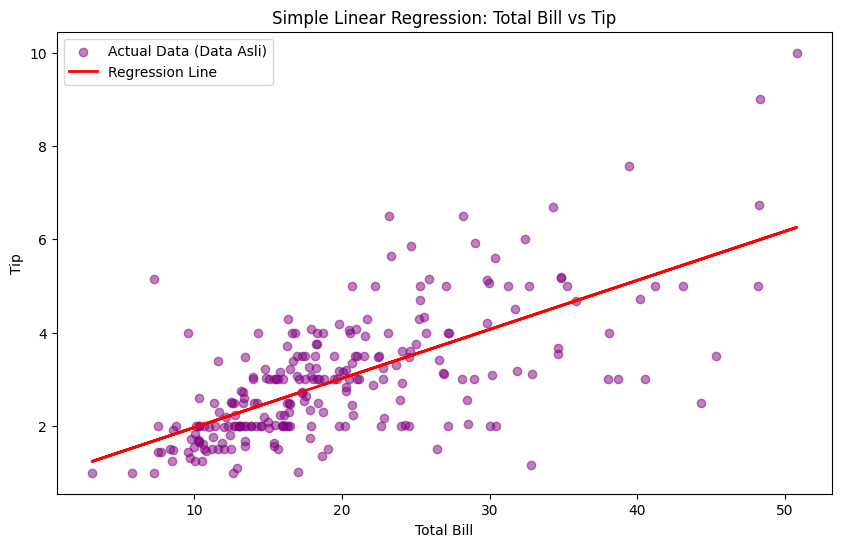

In [2]:
# =================================================================
# BAGIAN 2: REGRESSION ANALYSIS (OUTPUT LENGKAP SESUAI SOAL)
# =================================================================
print("=== HASIL LENGKAP: REGRESSION ANALYSIS ===")

# Persiapan data (Minimal 3 Fitur)
X = sns.load_dataset('tips')[['total_bill', 'size']].copy()
X['guest_ratio'] = X['total_bill'] / X['size'] # Fitur ke-3
y = sns.load_dataset('tips')['tip'].values

# --- 1. Simple Linear Regression & Visualisasi UNGU ---
model_s = LinearRegression().fit(X[['total_bill']], y)
print("1. Simple Linear Regression (Total Bill vs Tip):")
print(f"   - Koefisien (Slope): {model_s.coef_[0]:.4f}")
print(f"   - Intersep         : {model_s.intercept_:.4f}")
print(f"   - Persamaan        : y = {model_s.intercept_:.4f} + {model_s.coef_[0]:.4f} * x\n")

plt.figure(figsize=(10, 6))
plt.scatter(X['total_bill'], y, color='purple', alpha=0.5, label='Actual Data (Data Asli)') # Warna Ungu
plt.plot(X['total_bill'], model_s.predict(X[['total_bill']]), color='red', linewidth=2, label='Regression Line')
plt.title("Simple Linear Regression: Total Bill vs Tip")
plt.xlabel("Total Bill")
plt.ylabel("Tip")
plt.legend()
plt.show()

Disini saya membuat model regresi paling dasar untuk melihat hubungan antara total_bill dengan ti. Saya juga menyertakan visualisasi grafis untuk melihat persebaran data asli dan garis prediksinya.
Dari hasil di atas, kita bisa melihat ada titik - titik bewarna ungu yang merupakan data asli pelanggan sedangkan garis merah yaitu menunjukkan arah prediksi model.

In [3]:
# --- 2. Multiple Linear Regression (3 Fitur) ---
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model_m = LinearRegression().fit(X_train, y_train)
y_pred_l = model_m.predict(X_test)
print(f"2. Multiple Linear Regression berhasil dibuat menggunakan fitur: {list(X.columns)}\n")

2. Multiple Linear Regression berhasil dibuat menggunakan fitur: ['total_bill', 'size', 'guest_ratio']



Pada program ini, saya mengembangkan model regresi dengan menggunakan tiga fitir yaitu, total_bill, size, dan guest_ratio. Kemudian data dibagi menjadi 2 bagian yaitu data training (80%) untuk melatih model dan data testing (20%) untuk menguji performa modelnya.
Dari hasil outputnya model Multiple Linear Regression telah berhasil dibangun menggunakan tiga variabel independen.

In [4]:
# --- 3. Perbandingan Degree 1 vs Degree 2 (Polynomial) ---
poly = PolynomialFeatures(degree=2)
model_p = LinearRegression().fit(poly.fit_transform(X_train), y_train)
r2_l = r2_score(y_test, y_pred_l)
r2_p = r2_score(y_test, model_p.predict(poly.transform(X_test)))

print("3. Perbandingan Akurasi Model:")
print(f"   - R2 Score Linear (Degree 1)    : {r2_l:.4f}")
print(f"   - R2 Score Polynomial (Degree 2): {r2_p:.4f}")
kesimpulan = "Polynomial" if r2_p > r2_l else "Linear"
print(f"   - KESIMPULAN: Model {kesimpulan} lebih baik karena memiliki skor R2 yang lebih tinggi.\n")


3. Perbandingan Akurasi Model:
   - R2 Score Linear (Degree 1)    : 0.4551
   - R2 Score Polynomial (Degree 2): 0.4658
   - KESIMPULAN: Model Polynomial lebih baik karena memiliki skor R2 yang lebih tinggi.



Pada program ini saya melakukan eksperimen untuk membandingkan akurasi antara model linear standar (Degree 1)dengan model polynomial Regresion (Degree 2). Tujuannya adalah untuk melihat apakah data memiliki pola hubungan yang melengkung (non-linear) yang bisa ditangkap lebih baik oleh model polynomial.
Hasil outputnya yaitu program ini menampilkan perbandingan nilai R2 Score dari kedua model. Dimana nilai R2 Score yang lebih tinggi menunjukkan bahwa model tersebut lebih akurat dalam menjelaskan variasi pada data tip.

In [5]:
# --- 4. Laporan Metrik Akhir ---
print("4. Laporan Metrik Evaluasi (Multiple Regression):")
print(f"   - MAE  (Mean Absolute Error)  : {mean_absolute_error(y_test, y_pred_l):.4f}")
print(f"   - RMSE (Root Mean Squared Error): {np.sqrt(mean_squared_error(y_test, y_pred_l)):.4f}")
print(f"   - R2 Score                    : {r2_score(y_test, y_pred_l):.4f}")

4. Laporan Metrik Evaluasi (Multiple Regression):
   - MAE  (Mean Absolute Error)  : 0.6934
   - RMSE (Root Mean Squared Error): 0.8253
   - R2 Score                    : 0.4551


Pada program ini saya menampilkan laporan metrik evaluasi secara menyeluruh untuk model Multiple Regression yang telah dibuat.
Dari outputnya yang dimana program ini menyajikan tiga metrik utama yaitu, MAE dan RMSE yang mempresentasikan besarnya rata - rata kesalahan prediksi serta R2 Score yang menunjukkan sejauh mana variabel independen mampu memprediksi vaariabel secara akurat.


#Kesimpulan
Berdasarkan dari program ini menunjukkan bahwa untuk memprediksi besaran tip, penggunaan banyak fitur dapat memberikan hasil yang lebih mendalam. Pemilihan antara model Linear atau Polynomial sangat bergantung pada nilai R2 yang dihasilkan. dan dengan menggunakan metrik evaluasi seperti MAE dan RMSE, kita bisa menjamin bahwa model yang kita buat memiliki tingkat kesalahan yang minim.